# LLM Data Preparation Pipeline

## Learning Objectives

1. **Describe** the end-to-end pipeline for building pretraining corpora for LLMs
2. **Implement** MinHash-based near-duplicate deduplication
3. **Explain** quality filtering heuristics (perplexity, rule-based, classifier-based)
4. **Demonstrate** text extraction and tokenization concepts
5. **Analyse** the effect of deduplication on data diversity


## The LLM Data Pipeline

### Stage 1: Collection

Sources: Common Crawl (petabytes of web HTML), books, code, Wikipedia, papers.

Extraction tool: **trafilatura** — a Python library that strips HTML boilerplate and extracts main content. Key operations:
- Removes navigation, ads, footers
- Handles encoding detection
- Falls back to readability-style heuristics

```python
import trafilatura
html = trafilatura.fetch_url("https://example.com")
text = trafilatura.extract(html, include_tables=False, deduplicate=True)
```

### Stage 2: Quality Filtering

**Rule-based heuristics** (Rae et al., 2021 — Gopher):
- Min/max word count
- Fraction of words that are stop words ≥ threshold
- Fraction of lines ending with punctuation ≥ threshold
- Symbol-to-word ratio (filter emoji-heavy or code-like text)

**Perplexity filtering** (CCNet, Wenzek et al., 2020):
- Train a small n-gram language model on high-quality text (Wikipedia)
- Score each document; keep only low-perplexity (fluent) documents
- Reduces perplexity gap between training data and downstream task

### Stage 3: Near-Duplicate Removal

**MinHash LSH** (Broder, 1997):
- Shingle each document into character n-grams
- Hash shingles with $k$ independent hash functions → MinHash signature
- Jaccard similarity $J(A,B) = |A \cap B| / |A \cup B|$ ≈ probability of min-hash collision
- Use LSH bands to find candidate near-duplicates without all-pairs comparison

Jaccard approximation: with $k$ hash functions, $\Pr[\min h(A) = \min h(B)] = J(A,B)$

LSH bands: split $k$ hashes into $b$ bands of $r$ rows. False-positive threshold: $t \approx (1/b)^{1/r}$

### Stage 4: Tokenization

**Byte-Pair Encoding (BPE)**: start with individual bytes, iteratively merge the most frequent pair:
$$\text{vocab} \leftarrow \text{vocab} \cup \{\text{merge}(p)\}, \quad \text{text} \leftarrow \text{apply\_merge}(\text{text})$$

GPT-4 uses ~100k BPE tokens. Llama uses SentencePiece BPE.


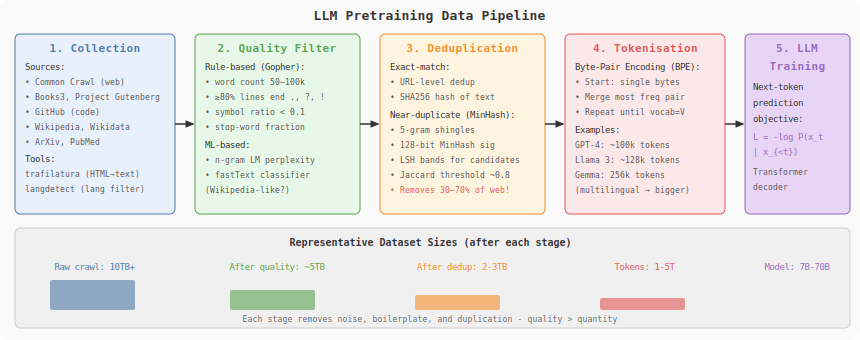

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="340" font-family="monospace" font-size="11">
  <rect width="860" height="340" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">LLM Pretraining Data Pipeline</text>

  <!-- Stage boxes -->
  <!-- 1. Collection -->
  <rect x="15" y="34" width="160" height="180" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="95" y="52" text-anchor="middle" fill="#4e79a7" font-weight="bold">1. Collection</text>
  <text x="25" y="70" fill="#333" font-size="9">Sources:</text>
  <text x="25" y="85" fill="#555" font-size="8">• Common Crawl (web)</text>
  <text x="25" y="100" fill="#555" font-size="8">• Books3, Project Gutenberg</text>
  <text x="25" y="115" fill="#555" font-size="8">• GitHub (code)</text>
  <text x="25" y="130" fill="#555" font-size="8">• Wikipedia, Wikidata</text>
  <text x="25" y="145" fill="#555" font-size="8">• ArXiv, PubMed</text>
  <text x="25" y="162" fill="#333" font-size="9">Tools:</text>
  <text x="25" y="177" fill="#555" font-size="8">trafilatura (HTML→text)</text>
  <text x="25" y="192" fill="#555" font-size="8">langdetect (lang filter)</text>

  <!-- Arrow -->
  <line x1="175" y1="124" x2="193" y2="124" stroke="#333" stroke-width="1.5" marker-end="url(#la1)"/>
  <defs><marker id="la1" markerWidth="6" markerHeight="5" refX="5" refY="2.5" orient="auto"><polygon points="0 0,6 2.5,0 5" fill="#333"/></marker></defs>

  <!-- 2. Quality filter -->
  <rect x="195" y="34" width="165" height="180" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="277" y="52" text-anchor="middle" fill="#59a14f" font-weight="bold">2. Quality Filter</text>
  <text x="205" y="70" fill="#333" font-size="9">Rule-based (Gopher):</text>
  <text x="205" y="85" fill="#555" font-size="8">• word count 50–100k</text>
  <text x="205" y="100" fill="#555" font-size="8">• ≥80% lines end ., ?, !</text>
  <text x="205" y="115" fill="#555" font-size="8">• symbol ratio &lt; 0.1</text>
  <text x="205" y="130" fill="#555" font-size="8">• stop-word fraction</text>
  <text x="205" y="148" fill="#333" font-size="9">ML-based:</text>
  <text x="205" y="163" fill="#555" font-size="8">• n-gram LM perplexity</text>
  <text x="205" y="178" fill="#555" font-size="8">• fastText classifier</text>
  <text x="205" y="193" fill="#555" font-size="8">  (Wikipedia-like?)</text>

  <!-- Arrow -->
  <line x1="360" y1="124" x2="378" y2="124" stroke="#333" stroke-width="1.5" marker-end="url(#la1)"/>

  <!-- 3. Deduplication -->
  <rect x="380" y="34" width="165" height="180" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="462" y="52" text-anchor="middle" fill="#f28e2b" font-weight="bold">3. Deduplication</text>
  <text x="390" y="70" fill="#333" font-size="9">Exact-match:</text>
  <text x="390" y="85" fill="#555" font-size="8">• URL-level dedup</text>
  <text x="390" y="100" fill="#555" font-size="8">• SHA256 hash of text</text>
  <text x="390" y="118" fill="#333" font-size="9">Near-duplicate (MinHash):</text>
  <text x="390" y="133" fill="#555" font-size="8">• 5-gram shingles</text>
  <text x="390" y="148" fill="#555" font-size="8">• 128-bit MinHash sig</text>
  <text x="390" y="163" fill="#555" font-size="8">• LSH bands for candidates</text>
  <text x="390" y="178" fill="#555" font-size="8">• Jaccard threshold ~0.8</text>
  <text x="390" y="193" fill="#e15759" font-size="8">• Removes 30–70% of web!</text>

  <!-- Arrow -->
  <line x1="545" y1="124" x2="563" y2="124" stroke="#333" stroke-width="1.5" marker-end="url(#la1)"/>

  <!-- 4. Tokenisation -->
  <rect x="565" y="34" width="160" height="180" rx="5" fill="#fce8e8" stroke="#e15759"/>
  <text x="645" y="52" text-anchor="middle" fill="#e15759" font-weight="bold">4. Tokenisation</text>
  <text x="575" y="70" fill="#333" font-size="9">Byte-Pair Encoding (BPE):</text>
  <text x="575" y="85" fill="#555" font-size="8">• Start: single bytes</text>
  <text x="575" y="100" fill="#555" font-size="8">• Merge most freq pair</text>
  <text x="575" y="115" fill="#555" font-size="8">• Repeat until vocab=V</text>
  <text x="575" y="133" fill="#333" font-size="9">Examples:</text>
  <text x="575" y="148" fill="#555" font-size="8">GPT-4:   ~100k tokens</text>
  <text x="575" y="163" fill="#555" font-size="8">Llama 3: ~128k tokens</text>
  <text x="575" y="178" fill="#555" font-size="8">Gemma:   256k tokens</text>
  <text x="575" y="193" fill="#555" font-size="8">(multilingual → bigger)</text>

  <!-- Arrow -->
  <line x1="725" y1="124" x2="743" y2="124" stroke="#333" stroke-width="1.5" marker-end="url(#la1)"/>

  <!-- 5. Training -->
  <rect x="745" y="34" width="105" height="180" rx="5" fill="#e8d5f5" stroke="#9467bd"/>
  <text x="797" y="52" text-anchor="middle" fill="#9467bd" font-weight="bold">5. LLM</text>
  <text x="797" y="70" text-anchor="middle" fill="#9467bd" font-weight="bold">Training</text>
  <text x="753" y="90" fill="#333" font-size="9">Next-token</text>
  <text x="753" y="106" fill="#333" font-size="9">prediction</text>
  <text x="753" y="122" fill="#333" font-size="9">objective:</text>
  <text x="753" y="140" fill="#9467bd" font-size="9">L = -log P(x_t</text>
  <text x="753" y="155" fill="#9467bd" font-size="9">  | x_{&lt;t})</text>
  <text x="753" y="175" fill="#555" font-size="8">Transformer</text>
  <text x="753" y="190" fill="#555" font-size="8">decoder</text>

  <!-- Stats bar -->
  <rect x="15" y="228" width="835" height="100" rx="5" fill="#f0f0f0" stroke="#ccc"/>
  <text x="430" y="246" text-anchor="middle" fill="#333" font-size="10" font-weight="bold">Representative Dataset Sizes (after each stage)</text>
  <text x="95" y="270" text-anchor="middle" fill="#4e79a7" font-size="9">Raw crawl: 10TB+</text>
  <text x="277" y="270" text-anchor="middle" fill="#59a14f" font-size="9">After quality: ~5TB</text>
  <text x="462" y="270" text-anchor="middle" fill="#f28e2b" font-size="9">After dedup: 2-3TB</text>
  <text x="645" y="270" text-anchor="middle" fill="#e15759" font-size="9">Tokens: 1-5T</text>
  <text x="797" y="270" text-anchor="middle" fill="#9467bd" font-size="9">Model: 7B-70B</text>
  <!-- Bar chart mock -->
  <rect x="50" y="280" width="85" height="30" fill="#4e79a7" opacity="0.6" rx="2"/>
  <rect x="230" y="290" width="85" height="20" fill="#59a14f" opacity="0.6" rx="2"/>
  <rect x="415" y="295" width="85" height="15" fill="#f28e2b" opacity="0.6" rx="2"/>
  <rect x="600" y="298" width="85" height="12" fill="#e15759" opacity="0.6" rx="2"/>
  <text x="430" y="322" text-anchor="middle" fill="#666" font-size="8">Each stage removes noise, boilerplate, and duplication  -  quality &gt; quantity</text>
</svg>
'''
display(SVG(svg))


In [2]:
import numpy as np
import hashlib
import re
from collections import Counter


# ── MinHash near-duplicate detection ─────────────────────────────────────────

def get_shingles(text, k=5):
    """Character k-gram shingles."""
    text = re.sub(r'\s+', ' ', text.lower())
    return set(text[i:i+k] for i in range(len(text) - k + 1))


def minhash_signature(shingles, n_hash=128, seed=42):
    """
    Compute MinHash signature: for each of n_hash functions,
    return the minimum hash value over all shingles.
    We simulate n_hash functions via seeded salted hashing.
    """
    sig = np.full(n_hash, np.inf)
    for shingle in shingles:
        for i in range(n_hash):
            h = int(hashlib.md5(f"{i}_{shingle}".encode()).hexdigest(), 16)
            if h < sig[i]:
                sig[i] = h
    return sig


def estimated_jaccard(sig_a, sig_b):
    "Fraction of matching min-hash slots ≈ Jaccard similarity."
    return np.mean(sig_a == sig_b)


def true_jaccard(set_a, set_b):
    """Exact Jaccard similarity."""
    ""
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


# ── Test documents ────────────────────────────────────────────────────────────
docs = [
    "The quick brown fox jumps over the lazy dog. This is a standard English pangram.",
    "The quick brown fox jumped over the lazy dog. This is a classic English pangram.",  # near-dup of 0
    "Machine learning is a subset of artificial intelligence that enables systems to learn from data.",
    "Artificial intelligence includes machine learning, which allows systems to learn from data automatically.",  # near-dup of 2
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris.",
]

print("Pairwise Jaccard similarities (true vs MinHash-estimated, 128 hashes):")
print(f"{'Pair':<10} {'True J':>8} {'MinHash J':>10} {'Near-dup?':>10}")
print("-" * 45)

threshold = 0.5
shingles_all = [get_shingles(d, k=5) for d in docs]

# Use fewer hashes for speed in demo (32 instead of 128)
n_hash = 32
rng = np.random.default_rng(0)

# Signature computed per doc
sigs = []
for shingles in shingles_all:
    sig = np.array([
        min(int(hashlib.md5(f"{i}_{s}".encode()).hexdigest(), 16) for s in shingles)
        for i in range(n_hash)
    ])
    sigs.append(sig)

for i in range(len(docs)):
    for j in range(i+1, len(docs)):
        tj = true_jaccard(shingles_all[i], shingles_all[j])
        mj = estimated_jaccard(sigs[i], sigs[j])
        flag = "YES" if tj >= threshold else "no"
        print(f"({i},{j})      {tj:8.3f} {mj:10.3f} {flag:>10}")


Pairwise Jaccard similarities (true vs MinHash-estimated, 128 hashes):
Pair         True J  MinHash J  Near-dup?
---------------------------------------------
(0,1)         0.634      0.625        YES
(0,2)         0.018      0.031         no
(0,3)         0.000      0.000         no
(0,4)         0.021      0.000         no
(1,2)         0.012      0.000         no
(1,3)         0.000      0.000         no
(1,4)         0.021      0.000         no
(2,3)         0.400      0.344         no
(2,4)         0.013      0.000         no
(3,4)         0.000      0.000         no


In [3]:
# ── LSH Banding: find candidate near-duplicates efficiently ───────────────────

def lsh_candidates(sigs, n_bands=8, rows_per_band=4):
    """
    Split each signature into b bands of r rows.
    Two docs are candidates if they hash to the same bucket in ANY band.
    """
    assert n_bands * rows_per_band <= sigs[0].shape[0]
    n_docs = len(sigs)
    candidates = set()

    for b in range(n_bands):
        start = b * rows_per_band
        end   = start + rows_per_band
        bucket = {}
        for doc_id, sig in enumerate(sigs):
            band_sig = tuple(int(x) if x < 1e18 else hash(x) for x in sig[start:end])
            key = (b, band_sig)
            if key in bucket:
                for prev_id in bucket[key]:
                    pair = (min(prev_id, doc_id), max(prev_id, doc_id))
                    candidates.add(pair)
                bucket[key].append(doc_id)
            else:
                bucket[key] = [doc_id]
    return candidates


candidates = lsh_candidates(sigs, n_bands=8, rows_per_band=4)
print("LSH candidate pairs (may contain false positives):")
for i, j in sorted(candidates):
    tj = true_jaccard(shingles_all[i], shingles_all[j])
    print(f"  Docs ({i},{j}): true Jaccard = {tj:.3f}")

print()
print("Pairs NOT found by LSH (miss = false negative):")
all_pairs = {(i,j) for i in range(len(docs)) for j in range(i+1, len(docs))}
for i, j in sorted(all_pairs - candidates):
    tj = true_jaccard(shingles_all[i], shingles_all[j])
    print(f"  Docs ({i},{j}): true Jaccard = {tj:.3f}")


LSH candidate pairs (may contain false positives):
  Docs (0,1): true Jaccard = 0.634

Pairs NOT found by LSH (miss = false negative):
  Docs (0,2): true Jaccard = 0.018
  Docs (0,3): true Jaccard = 0.000
  Docs (0,4): true Jaccard = 0.021
  Docs (1,2): true Jaccard = 0.012
  Docs (1,3): true Jaccard = 0.000
  Docs (1,4): true Jaccard = 0.021
  Docs (2,3): true Jaccard = 0.400
  Docs (2,4): true Jaccard = 0.013
  Docs (3,4): true Jaccard = 0.000


In [4]:
# ── Quality Filtering: rule-based heuristics ──────────────────────────────────

def quality_score(text):
    words = text.split()
    n_words = len(words)
    if n_words == 0:
        return 0.0, ["empty"]

    issues = []

    # Word count filter
    if n_words < 20:
        issues.append(f"too short ({n_words} words)")

    # Symbol ratio (non-alpha characters / words)
    n_symbols = sum(1 for c in text if not c.isalnum() and not c.isspace())
    symbol_ratio = n_symbols / n_words
    if symbol_ratio > 3.0:
        issues.append(f"symbol-heavy ({symbol_ratio:.1f} symbols/word)")

    # Stop-word fraction (simplified: check common stop words)
    stop_words = {'the','a','an','is','it','in','of','and','to','for','that','this','with','on','at'}
    stop_count = sum(1 for w in words if w.lower() in stop_words)
    stop_fraction = stop_count / n_words
    if stop_fraction < 0.05:
        issues.append(f"low stop-word fraction ({stop_fraction:.2f})")

    # Fraction of lines ending with punctuation
    lines = [l.strip() for l in text.split('.') if l.strip()]
    score = max(0.0, 1.0 - 0.5 * len(issues))
    return score, issues


test_texts = [
    "The quick brown fox jumps over the lazy dog. This is a well-formed English sentence.",
    "BUY NOW!!! CLICK HERE!!! 50% OFF!!! LIMITED TIME OFFER!!!",
    "ok",
    "In 2024, the global AI market was valued at approximately $142 billion, with projections indicating continued growth through the decade.",
    "#!/usr/bin/env python\n# -*- coding: utf-8 -*-\nimport sys\nfrom pathlib import Path",
]

print("Quality filtering results:")
print(f"{'Text (first 50 chars)':<52} {'Score':>6} {'Issues'}")
print("-" * 90)
for text in test_texts:
    score, issues = quality_score(text)
    snippet = text[:50].replace('\n', '↵')
    issue_str = ", ".join(issues) if issues else "pass"
    print(f"{snippet:<52} {score:>6.2f}  {issue_str}")


Quality filtering results:
Text (first 50 chars)                                 Score Issues
------------------------------------------------------------------------------------------
The quick brown fox jumps over the lazy dog. This      0.50  too short (15 words)
BUY NOW!!! CLICK HERE!!! 50% OFF!!! LIMITED TIME O     0.00  too short (9 words), low stop-word fraction (0.00)
ok                                                     0.00  too short (1 words), low stop-word fraction (0.00)
In 2024, the global AI market was valued at approx     1.00  pass
#!/usr/bin/env python↵# -*- coding: utf-8 -*-↵impo     0.00  too short (13 words), low stop-word fraction (0.00)


In [5]:
# ── Byte-Pair Encoding (BPE) implementation ───────────────────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import defaultdict


def get_vocab(texts):
    """Build initial vocabulary: split each word into chars + end-of-word marker."""
    vocab = defaultdict(int)
    for text in texts:
        for word in text.lower().split():
            word_chars = ' '.join(list(word)) + ' </w>'
            vocab[word_chars] += 1
    return dict(vocab)


def get_pairs(vocab):
    "Count all adjacent symbol pairs."
    pairs = defaultdict(int)
    for word, count in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += count
    return dict(pairs)


def merge_vocab(pair, vocab):
    """Apply one BPE merge step."""
    ""
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    new_vocab = {}
    for word, count in vocab.items():
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = count
    return new_vocab


# Run BPE on a tiny corpus
corpus = [
    "low lower lowest",
    "newer newer new",
    "low new new new newer",
    "lowest lower",
]

vocab = get_vocab(corpus)
print("Initial vocabulary (character-level):")
for token, count in sorted(vocab.items(), key=lambda x: -x[1])[:8]:
    print(f"  {token!r:<30}  count={count}")

merge_history = []
for step in range(12):
    pairs = get_pairs(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    merge_history.append((best, pairs[best]))

print("\nBPE merge steps (most frequent pair merged each step):")
for i, (pair, count) in enumerate(merge_history):
    print(f"  Step {i+1:2d}: merge {pair[0]!r} + {pair[1]!r} → {''.join(pair)!r}  (freq={count})")

print("\nFinal vocabulary after 12 merges:")
for token, count in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f"  {token!r:<25}  count={count}")

# Plot merge frequency decay
freqs = [c for _, c in merge_history]
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, len(freqs)+1), freqs, color='#4e79a7', alpha=0.8)
ax.set_xlabel("Merge step")
ax.set_ylabel("Frequency of merged pair")
ax.set_title("BPE: Merge Pair Frequencies (frequency drops as rare pairs are merged)")
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("bpe_merges.png", dpi=110)
plt.show()
print("Saved bpe_merges.png")


Initial vocabulary (character-level):
  'n e w </w>'                    count=4
  'n e w e r </w>'                count=3
  'l o w </w>'                    count=2
  'l o w e r </w>'                count=2
  'l o w e s t </w>'              count=2

BPE merge steps (most frequent pair merged each step):
  Step  1: merge 'w' + 'e' → 'we'  (freq=7)
  Step  2: merge 'n' + 'e' → 'ne'  (freq=7)
  Step  3: merge 'l' + 'o' → 'lo'  (freq=6)
  Step  4: merge 'w' + '</w>' → 'w</w>'  (freq=6)
  Step  5: merge 'we' + 'r' → 'wer'  (freq=5)
  Step  6: merge 'wer' + '</w>' → 'wer</w>'  (freq=5)
  Step  7: merge 'ne' + 'w</w>' → 'new</w>'  (freq=4)
  Step  8: merge 'ne' + 'wer</w>' → 'newer</w>'  (freq=3)
  Step  9: merge 'lo' + 'w</w>' → 'low</w>'  (freq=2)
  Step 10: merge 'lo' + 'wer</w>' → 'lower</w>'  (freq=2)
  Step 11: merge 'lo' + 'we' → 'lowe'  (freq=2)
  Step 12: merge 'lowe' + 's' → 'lowes'  (freq=2)

Final vocabulary after 12 merges:
  'new</w>'                  count=4
  'newer</w>'       

Saved bpe_merges.png


/tmp/ipykernel_306024/2164810426.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

| Stage | Goal | Key Tool |
|---|---|---|
| Collection | Gather raw text from diverse sources | trafilatura, wget |
| Quality filtering | Remove low-quality/spammy content | Rule-based heuristics, LM perplexity |
| Deduplication | Remove near-identical documents | MinHash + LSH |
| Tokenisation | Convert text to integer token IDs | BPE (tiktoken, SentencePiece) |

### Key Numbers (GPT-3 scale)

- Raw Common Crawl: ~45TB HTML
- After extraction: ~750GB text
- After dedup + quality filter: ~570GB
- Tokens (GPT-2 tokenizer): ~300B tokens
- GPT-3 trained on: ~300B tokens, 175B parameters

### Impact of Deduplication

Carlini et al. (2022): models memorise duplicated training examples. Deduplication:
1. Reduces memorisation of private/sensitive content
2. Improves data diversity → better generalisation
3. Makes evaluation more honest (test data less likely to appear verbatim)

Typically removes 30–70% of crawl data at Jaccard threshold 0.8.
